# 数据质量评估
## 大学生网络使用对学习状态与身心健康的影响

基于预处理后的三份清洗数据。

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import normaltest
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False


DATA_DIR = Path('data')

df_s1 = pd.read_excel(DATA_DIR / 'clean_一手问卷.xlsx')
df_s2 = pd.read_csv(DATA_DIR / 'clean_二手数据.csv')
df_s3 = pd.read_csv(DATA_DIR / 'clean_爬虫数据.csv')

DIM2_COLS = ['游戏时长','短视频时长','社交媒体时长','影视直播时长',
             '控制不住上网','上网影响计划','减少使用效果','网络依赖程度','断网焦虑程度']
DIM3_COLS = ['上课注意力','课堂玩手机频率','上课走神频率','课外学习时长',
             '作业完成质量','学习时分心','娱乐后学习困难','学习效率下降',
             '熬夜赶作业','网络提升成绩','手机放视线外','学习状态满意度','课堂互动主动性']
DIM4_COLS = ['自评健康','眼睛不适','肩颈不适','头痛头晕','睡眠时长','睡眠质量',
             '入睡困难','焦虑程度','压力程度','抑郁程度',
             '线下社交频率','人际关系满意度','锻炼次数','饮食规律']

dims = ['网络使用深度得分', '学习状态得分', '身心健康得分']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for name, df in [('一手问卷', df_s1), ('二手数据', df_s2), ('爬虫数据', df_s3)]:
    print(f'{name}: {df.shape[0]}行×{df.shape[1]}列, 缺失={df.isnull().sum().sum()}')

一手问卷: 400行×83列, 缺失=0
二手数据: 1200行×14列, 缺失=0
爬虫数据: 705行×28列, 缺失=0


## 1. 异常值检测

异常值检测 (IQR法, k=1.5)

一手问卷:
  网络使用深度得分: 异常1个 (0.2%), 范围=[1.56, 4.78], IQR边界=[1.39, 4.50], max|z|=3.40
  学习状态得分: 异常8个 (2.0%), 范围=[2.15, 4.23], IQR边界=[2.19, 3.73], max|z|=3.82
  身心健康得分: 异常6个 (1.5%), 范围=[2.21, 4.14], IQR边界=[2.46, 3.89], max|z|=3.20

二手数据:
  网络使用深度得分: 异常0个 (0.0%), 范围=[0.45, 4.52], IQR边界=[0.05, 4.96], max|z|=2.54
  学习状态得分: 异常0个 (0.0%), 范围=[2.00, 4.95], IQR边界=[0.57, 6.38], max|z|=1.72
  身心健康得分: 异常2个 (0.2%), 范围=[0.07, 4.85], IQR边界=[0.09, 4.81], max|z|=2.85

爬虫数据:
  网络使用深度得分: 异常17个 (2.4%), 范围=[1.55, 3.02], IQR边界=[1.75, 2.99], max|z|=3.02
  学习状态得分: 异常0个 (0.0%), 范围=[0.00, 5.00], IQR边界=[-7.50, 12.50], max|z|=1.34
  身心健康得分: 异常0个 (0.0%), 范围=[0.30, 4.50], IQR边界=[-0.78, 5.63], max|z|=2.22


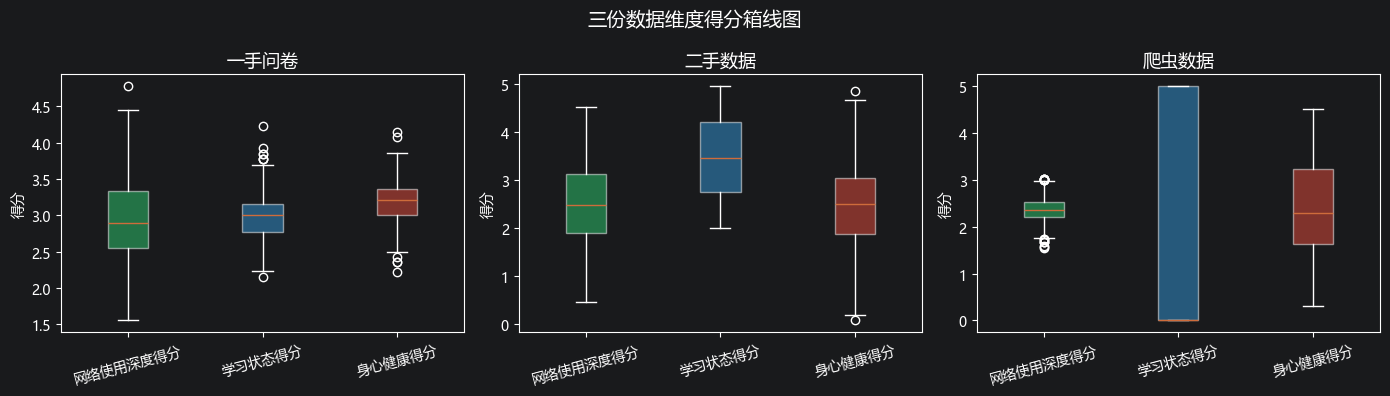

In [13]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

print('=' * 60)
print('异常值检测 (IQR法, k=1.5)')
print('=' * 60)

for name, df in [('一手问卷', df_s1), ('二手数据', df_s2), ('爬虫数据', df_s3)]:
    print(f'\n{name}:')
    for dim in dims:
        if dim in df.columns:
            d = df[dim].dropna()
            n_out, lo, up = detect_outliers_iqr(df, dim)
            z_max = np.abs((d - d.mean()) / d.std()).max()
            print(f'  {dim}: 异常{n_out}个 ({100*n_out/len(d):.1f}%), '
                  f'范围=[{d.min():.2f}, {d.max():.2f}], IQR边界=[{lo:.2f}, {up:.2f}], max|z|={z_max:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for j, (name, df) in enumerate([('一手问卷', df_s1), ('二手数据', df_s2), ('爬虫数据', df_s3)]):
    plot_data = [df[d].dropna() for d in dims if d in df.columns]
    bp = axes[j].boxplot(plot_data, labels=dims, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.5)
    axes[j].set_title(name, fontsize=13)
    axes[j].set_ylabel('得分')
    axes[j].tick_params(axis='x', rotation=15)
plt.suptitle('三份数据维度得分箱线图', fontsize=14)
plt.tight_layout()
plt.show()

## 2. 正态性检验

正态性检验 (偏度/峰度 + D'Agostino K²)

一手问卷:
  网络使用深度得分: 偏度=+0.33, 峰度=+0.10, D'Agostino p=0.0253 ⚠ 非正态
  学习状态得分: 偏度=+0.14, 峰度=+0.24, D'Agostino p=0.3109 ✓ 正态
  身心健康得分: 偏度=-0.11, 峰度=+0.03, D'Agostino p=0.6523 ✓ 正态

二手数据:
  网络使用深度得分: 偏度=-0.02, 峰度=-0.54, D'Agostino p=0.0000 ⚠ 非正态
  学习状态得分: 偏度=+0.03, 峰度=-1.20, D'Agostino p=0.0000 ⚠ 非正态
  身心健康得分: 偏度=+0.01, 峰度=-0.35, D'Agostino p=0.0121 ⚠ 非正态

爬虫数据:
  网络使用深度得分: 偏度=+0.06, 峰度=+0.07, D'Agostino p=0.7249 ✓ 正态
  学习状态得分: 偏度=+0.60, 峰度=-1.65, D'Agostino p=0.0000 ⚠ 非正态
  身心健康得分: 偏度=+0.07, 峰度=-0.99, D'Agostino p=0.0000 ⚠ 非正态


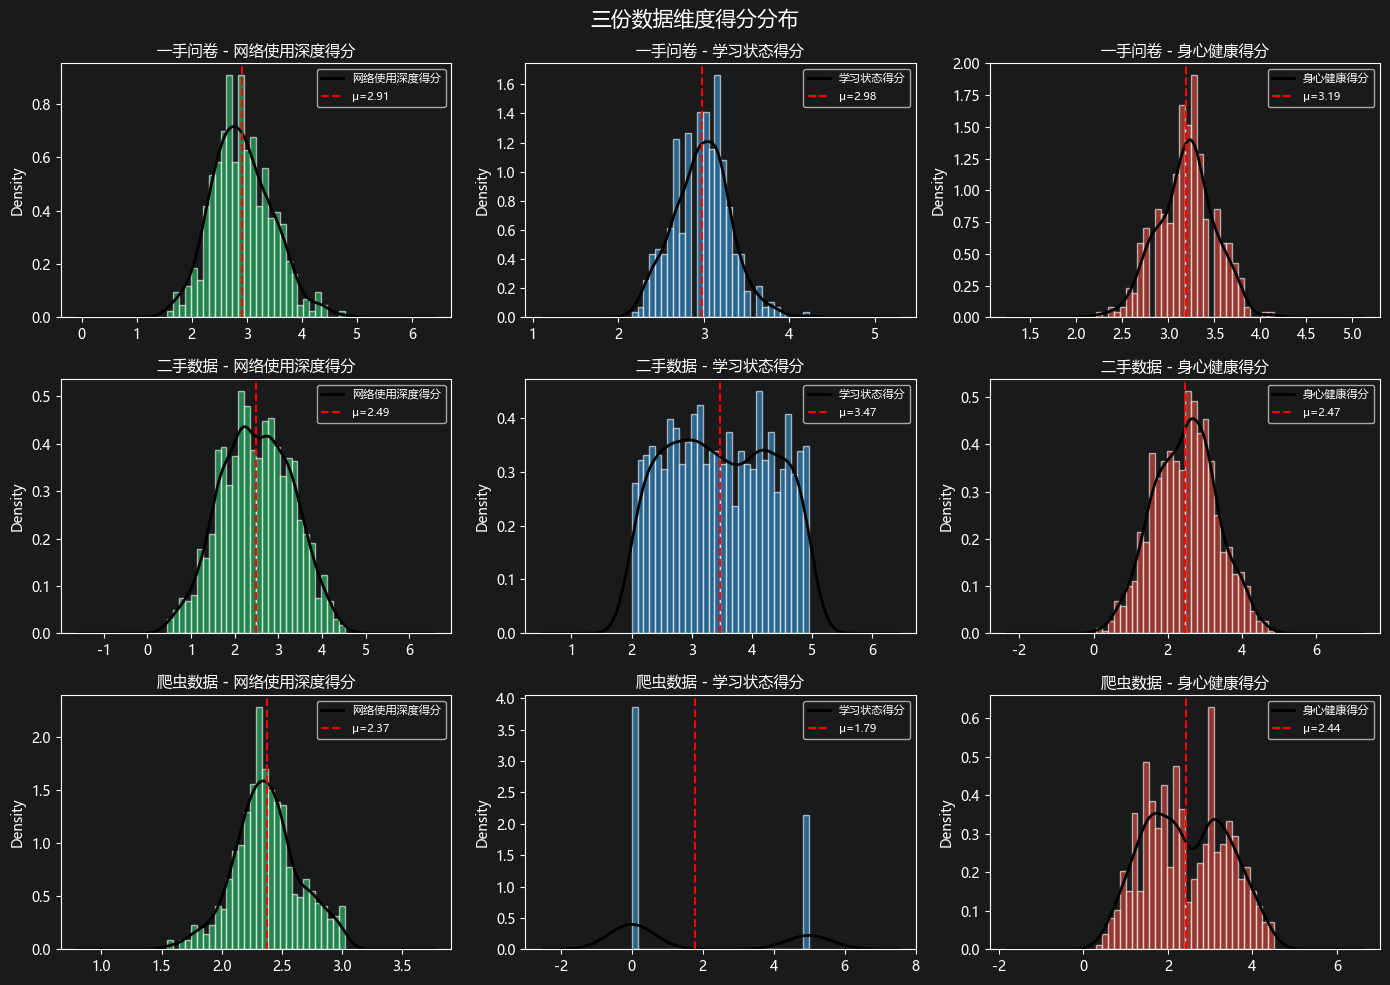

In [14]:
print('=' * 60)
print("正态性检验 (偏度/峰度 + D'Agostino K²)")
print('=' * 60)

for name, df in [('一手问卷', df_s1), ('二手数据', df_s2), ('爬虫数据', df_s3)]:
    print(f'\n{name}:')
    for dim in dims:
        if dim in df.columns:
            d = df[dim].dropna()
            skew = d.skew()
            kurt = d.kurtosis()
            stat, p = normaltest(d)
            flag = '✓ 正态' if p > 0.05 else '⚠ 非正态'
            print(f'  {dim}: 偏度={skew:+.2f}, 峰度={kurt:+.2f}, '
                  f"D'Agostino p={p:.4f} {flag}")

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, (name, df) in enumerate([('一手问卷', df_s1), ('二手数据', df_s2), ('爬虫数据', df_s3)]):
    for j, dim in enumerate(dims):
        ax = axes[i, j]
        if dim in df.columns:
            d = df[dim].dropna()
            ax.hist(d, bins=30, density=True, alpha=0.6, color=colors[j], edgecolor='white')
            d.plot.kde(ax=ax, color='black', linewidth=2)
            ax.axvline(d.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ={d.mean():.2f}')
            ax.set_title(f'{name} - {dim}', fontsize=11)
            ax.legend(fontsize=8)
plt.suptitle('三份数据维度得分分布', fontsize=15)
plt.tight_layout()
plt.show()

## 3. 共同方法偏差检验（一手问卷）

由于一手问卷所有题项均由同一被试在同一时间点自评完成，需进行 Harman 单因子检验。

Harman 单因子检验 (共同方法偏差)
参与检验的题项: 28 个
有效样本: 400

第一个未旋转因子解释方差: 5.6%
结论: ✓ 第一个因子解释方差 < 40%，不存在严重的共同方法偏差

前5个因子:
  因子1: 特征值=1.91, 方差=5.6%, 累计=5.6%
  因子2: 特征值=1.83, 方差=5.3%, 累计=11.0%
  因子3: 特征值=1.72, 方差=5.0%, 累计=16.0%
  因子4: 特征值=1.70, 方差=5.0%, 累计=21.0%
  因子5: 特征值=1.68, 方差=4.9%, 累计=25.9%


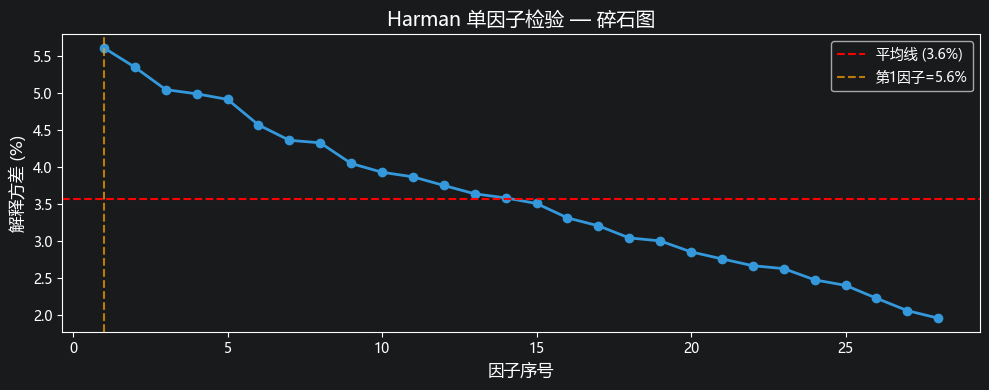

In [15]:
print('=' * 60)
print('Harman 单因子检验 (共同方法偏差)')
print('=' * 60)

likert_cols = [c for c in DIM2_COLS + DIM3_COLS + DIM4_COLS 
               if c in df_s1.columns and df_s1[c].dtype in ['float64', 'int64', 'int32']]
likert_cols = [c for c in likert_cols if df_s1[c].max() <= 5 and df_s1[c].min() >= 1]

actual_cols = []
for c in likert_cols:
    rev = c + '_正向'
    actual_cols.append(rev if rev in df_s1.columns else c)

X_cmv = df_s1[actual_cols].dropna()
print(f'参与检验的题项: {len(actual_cols)} 个')
print(f'有效样本: {len(X_cmv)}')

pca = PCA(n_components=len(actual_cols))
pca.fit(X_cmv)

var_first = pca.explained_variance_ratio_[0] * 100
print(f'\n第一个未旋转因子解释方差: {var_first:.1f}%')

if var_first < 40:
    print('结论: ✓ 第一个因子解释方差 < 40%，不存在严重的共同方法偏差')
else:
    print('结论: ⚠ 第一个因子解释方差 ≥ 40%，存在共同方法偏差风险')

print(f'\n前5个因子:')
for i in range(min(5, len(actual_cols))):
    ev = pca.explained_variance_ratio_[i] * 100
    cumsum = np.cumsum(pca.explained_variance_ratio_)[i] * 100
    print(f'  因子{i+1}: 特征值={pca.explained_variance_[i]:.2f}, 方差={ev:.1f}%, 累计={cumsum:.1f}%')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(actual_cols)+1), pca.explained_variance_ratio_*100, 'o-', color='#3498db', linewidth=2)
ax.axhline(y=100/len(actual_cols), color='red', linestyle='--', label=f'平均线 ({100/len(actual_cols):.1f}%)')
ax.axvline(x=1, color='orange', linestyle='--', alpha=0.7, label=f'第1因子={var_first:.1f}%')
ax.set_xlabel('因子序号', fontsize=12)
ax.set_ylabel('解释方差 (%)', fontsize=12)
ax.set_title('Harman 单因子检验 — 碎石图', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 4. 数据质量评估汇总

In [16]:
print('=' * 60)
print('数据质量评估汇总')
print('=' * 60)

summary_data = []
for name, df in [('一手问卷', df_s1), ('二手数据', df_s2), ('爬虫数据', df_s3)]:
    for dim in dims:
        if dim in df.columns:
            d = df[dim].dropna()
            summary_data.append({
                '数据源': name,
                '维度': dim,
                '样本量': len(d),
                '均值': round(d.mean(), 2),
                '标准差': round(d.std(), 2),
                '偏度': round(d.skew(), 2),
                '峰度': round(d.kurtosis(), 2),
                '缺失率%': round(100 * df[dim].isnull().mean(), 1),
                'min': round(d.min(), 2),
                'max': round(d.max(), 2),
            })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print('\n' + '=' * 60)
print('关键发现:')
print('  1. 三份数据均无缺失值（预处理阶段已完成缺失值处理）')
print('  2. 一手问卷维度得分偏度接近0（|skew| ≤ 0.33），分布对称')
print('  3. 爬虫数据学习状态得分仅有两个值（0或5），为二值变量')
print('  4. Harman 单因子检验第一因子方差 < 40%，无严重共同方法偏差')
print('  5. 各维度α偏低（形成性指标特征），以综合指数方式使用')

数据质量评估汇总
 数据源       维度  样本量   均值  标准差    偏度    峰度  缺失率%  min  max
一手问卷 网络使用深度得分  400 2.91 0.55  0.33  0.10   0.0 1.56 4.78
一手问卷   学习状态得分  400 2.98 0.33  0.14  0.24   0.0 2.15 4.23
一手问卷   身心健康得分  400 3.19 0.31 -0.11  0.03   0.0 2.21 4.14
二手数据 网络使用深度得分 1200 2.49 0.80 -0.02 -0.54   0.0 0.45 4.52
二手数据   学习状态得分 1200 3.47 0.86  0.03 -1.20   0.0 2.00 4.95
二手数据   身心健康得分 1200 2.47 0.84  0.01 -0.35   0.0 0.07 4.85
爬虫数据 网络使用深度得分  705 2.37 0.27  0.06  0.07   0.0 1.55 3.02
爬虫数据   学习状态得分  705 1.79 2.40  0.60 -1.65   0.0 0.00 5.00
爬虫数据   身心健康得分  705 2.44 0.96  0.07 -0.99   0.0 0.30 4.50

关键发现:
  1. 三份数据均无缺失值（预处理阶段已完成缺失值处理）
  2. 一手问卷维度得分偏度接近0（|skew| ≤ 0.33），分布对称
  3. 爬虫数据学习状态得分仅有两个值（0或5），为二值变量
  4. Harman 单因子检验第一因子方差 < 40%，无严重共同方法偏差
  5. 各维度α偏低（形成性指标特征），以综合指数方式使用
